# 통합 데이터 모델 — 최종본 (T1 A/B/C 사후시뮬레이션 검증 + T2 확장 재탐색)

`time_table_05_08.csv`(5-8월 전체, n=45) 하나로 T1·T2를 서로 다른 방식으로 마무리한다.

- **T1**: 5-7월(train, n=36)에서 모델을 확정하고, 8월(test, n=9)을 노션에 기록된 **A/B/C 사후시뮬레이션** 방식으로 검증한다. → **confirmatory**
  - A: 사장님 감각 기반 초벌 투입량(20kg) 오차
  - B: 모델 예측 오차
  - C: 일평균 고정값(baseline) 오차
  - 판정 기준: B 오차 < A 오차 **그리고** B 오차 < C 오차 → 그날은 "승"
- **T2**: 5-7월에서는 신뢰할 만한 피처를 못 찾았으므로, 홀드아웃을 포기하고 5-8월 전체(n=39)로 재탐색한다. → **exploratory** (검증 기회 없음, 이후 데이터로 재확인 필요)


## 설정 및 데이터 준비

In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import subprocess
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 적용:', plt.rcParams['font.family'])


import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("✅ 라이브러리 로드 완료")


폰트 적용: ['NanumGothic']
✅ 라이브러리 로드 완료


In [26]:
data = pd.read_csv('/content/time_table_05_08.csv')
data['date'] = pd.to_datetime(data['date'])
data['before_rest'] = pd.to_numeric(data['before_rest'])
data['rain_status'] = pd.to_numeric(data['rain_status'])

day_order = pd.CategoricalDtype(categories=['월', '화', '금'], ordered=False)
data['day_of_week'] = data['day_of_week'].astype(day_order)
day_dummies = pd.get_dummies(data['day_of_week'], drop_first=True, dtype=int)  # 월요일 기준(baseline)
data = pd.concat([data, day_dummies], axis=1)

train = data[data['date'] < '2026-08-01'].reset_index(drop=True)
test = data[data['date'] >= '2026-08-01'].reset_index(drop=True)

print(f"전체: {len(data)}행 (2026-05-11 ~ 2026-08-21)")
print(f"train(5-7월): {len(train)}행 / test(8월, 홀드아웃): {len(test)}행")


전체: 45행 (2026-05-11 ~ 2026-08-21)
train(5-7월): 36행 / test(8월, 홀드아웃): 9행


## 피처 상관관계 히트맵 (train 기준)

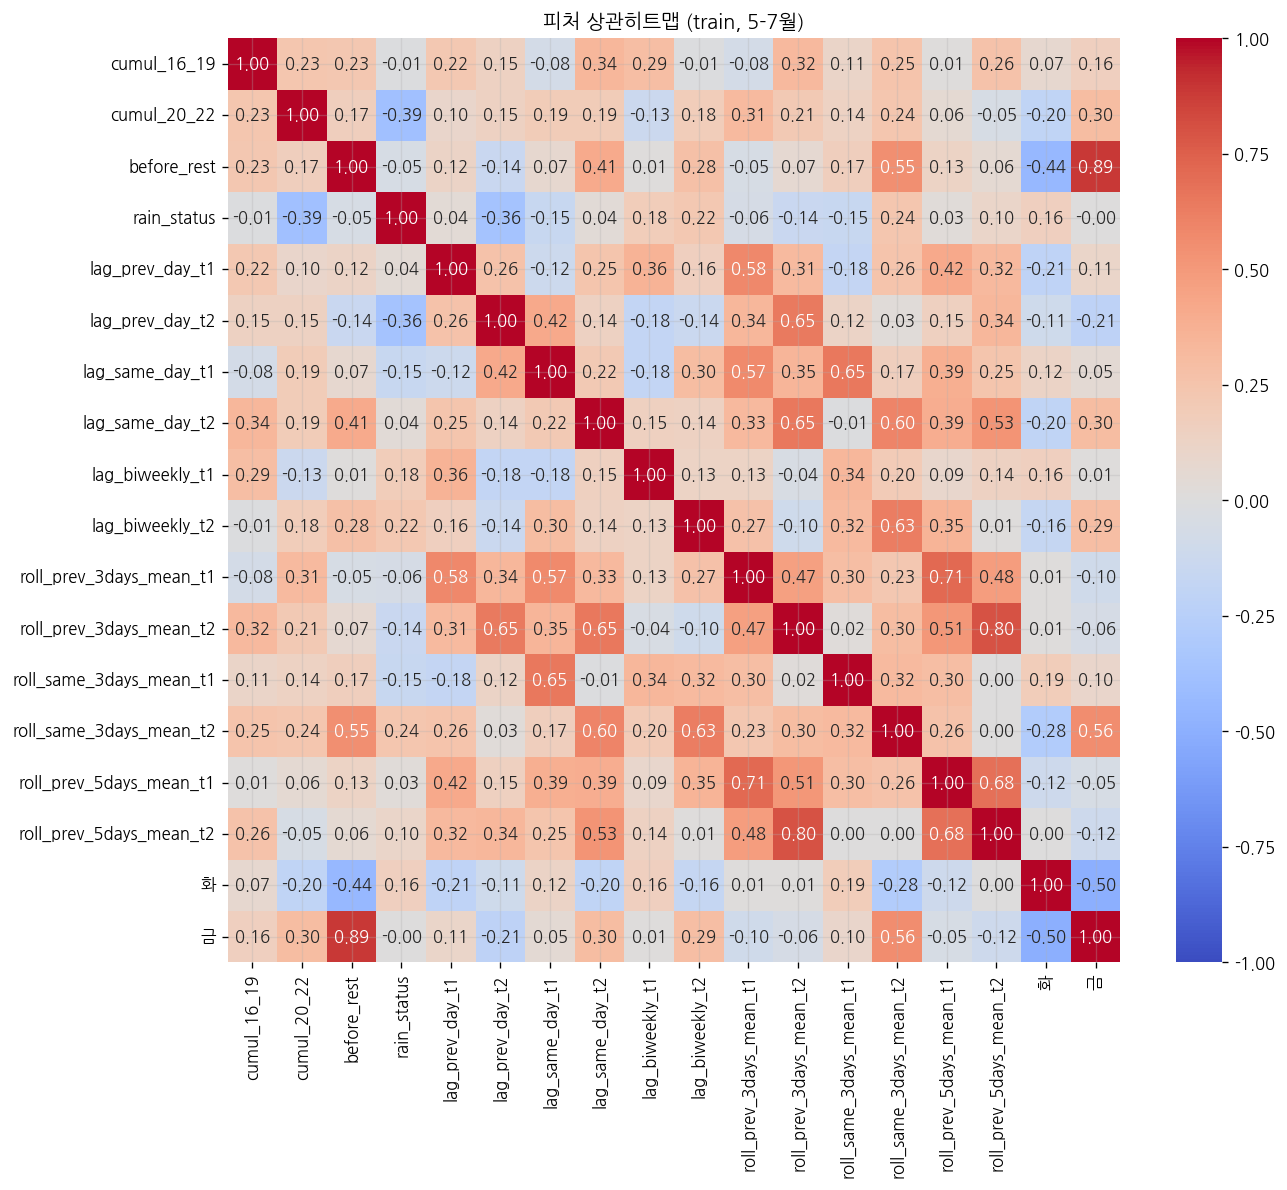

In [27]:
corr_col = ['cumul_16_19', 'cumul_20_22', 'before_rest', 'rain_status',
    'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1',
    'lag_same_day_t2', 'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
    'roll_same_3days_mean_t1', 'roll_same_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금']

corr_matrix = train[corr_col].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("피처 상관히트맵 (train, 5-7월)")
plt.show()


---
## LOOCV 기반 전진선택 + 안정성 검증 — 함수 정의

- `loocv_rmse`: 주어진 피처 조합 하나의 LOOCV RMSE
- `forward_selection`: baseline에서 시작해 RMSE를 `margin` 이상 낮추는 피처를 하나씩 채택

In [28]:
def loocv_rmse(X, y):
    loo = LeaveOneOut()
    y_true_list, y_pred_list = [], []
    for tr_idx, te_idx in loo.split(X):
        Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
        ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
        m = LinearRegression().fit(Xtr, ytr)
        pred = m.predict(Xte)
        y_true_list.append(yte.values[0]); y_pred_list.append(pred[0])
    return np.sqrt(mean_squared_error(y_true_list, y_pred_list))


def forward_selection(df, target, base_features, candidate_features,
                       max_features=5, margin=30.0, verbose=True):
    y = df[target]
    selected = base_features.copy()
    remaining = candidate_features.copy()

    if len(selected) == 0:
        X_start = pd.DataFrame({'const': np.ones(len(df))})
        current_rmse = loocv_rmse(X_start, y)
    else:
        current_rmse = loocv_rmse(df[selected], y)

    if verbose:
        print(f"[시작] baseline={selected if selected else '(피처 없음, 평균값만으로 잔차확인)'} → RMSE={current_rmse:.2f}\n")

    while remaining and len(selected) < max_features:
        best_candidate, best_rmse = None, current_rmse
        for feat in remaining:
            trial_rmse = loocv_rmse(df[selected + [feat]], y)
            if verbose:
                print(f"  시도: {selected} + [{feat}] → RMSE={trial_rmse:.2f}")
            if trial_rmse < best_rmse - margin:
                best_rmse, best_candidate = trial_rmse, feat
        if best_candidate is None:
            if verbose:
                print("\n→ 더 이상 개선되는 피처 없음. 선택 종료\n")
            break
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_rmse = best_rmse
        if verbose:
            print(f"[채택] '{best_candidate}' 추가 → RMSE={current_rmse:.2f}\n")

    return selected, current_rmse


def abc_simulation(dates, day_of_week, actual, pred_model, a_value, c_value):
    """
    노션 '모델 검증 — 사후 시뮬레이션' 방식 그대로 구현.
    A: 감각 기반 고정값 오차 / B: 모델 예측 오차 / C: 일평균 고정값 오차
    판정: B가 A·C 둘 다 이겨야 그날은 '승'
    """
    result = pd.DataFrame({
        'date': dates, 'day_of_week': day_of_week, '실제값': actual,
        'A_감각': a_value, 'B_모델': np.round(pred_model, 0), 'C_일평균': c_value,
    })
    # 절대오차 (MAE용) — 기존 그대로
    result['A_오차'] = (result['실제값'] - result['A_감각']).abs()
    result['B_오차'] = (result['실제값'] - result['B_모델']).abs()
    result['C_오차'] = (result['실제값'] - result['C_일평균']).abs()

    # 제곱오차 (MSE·RMSE용) — 신규 추가
    result['A_제곱오차'] = (result['실제값'] - result['A_감각']) ** 2
    result['B_제곱오차'] = (result['실제값'] - result['B_모델']) ** 2
    result['C_제곱오차'] = (result['실제값'] - result['C_일평균']) ** 2

    result['B안_승패'] = np.where(
        (result['B_오차'] < result['A_오차']) & (result['B_오차'] < result['C_오차']), '승', '패'
    )
    return result





---
# T1 — cumul_16_19 (confirmatory: train 확정 → 8월 A/B/C 사후시뮬레이션 검증)

## T1-1. train(5-7월)에서 전진선택

In [29]:
candidates_t1 = [
    'before_rest', 'rain_status', 'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금',
]

common_cols_t1 = candidates_t1 + ['cumul_16_19']
df_common_t1 = train.dropna(subset=common_cols_t1).reset_index(drop=True)

print(f"train 공통 표본 크기: {len(df_common_t1)}행")
print(f"타겟 표준편차: {df_common_t1['cumul_16_19'].std():.2f}\n")

selected_t1, rmse_t1 = forward_selection(
    df=df_common_t1, target='cumul_16_19',
    base_features=[], candidate_features=candidates_t1,
    max_features=4, margin=40,
)

print("=" * 50)
print(f"[T1 최종 선택 피처] {selected_t1}")
print(f"[T1 train LOOCV RMSE] {rmse_t1:.2f}")
print(f"[비교 기준] std = {df_common_t1['cumul_16_19'].std():.2f}")


train 공통 표본 크기: 30행
타겟 표준편차: 3107.40

[시작] baseline=(피처 없음, 평균값만으로 잔차확인) → RMSE=3160.52

  시도: [] + [before_rest] → RMSE=3075.11
  시도: [] + [rain_status] → RMSE=3255.09
  시도: [] + [lag_prev_day_t1] → RMSE=3255.83
  시도: [] + [lag_prev_day_t2] → RMSE=3245.14
  시도: [] + [lag_same_day_t1] → RMSE=3235.68
  시도: [] + [lag_same_day_t2] → RMSE=3062.25
  시도: [] + [lag_biweekly_t1] → RMSE=3120.86
  시도: [] + [lag_biweekly_t2] → RMSE=3236.04
  시도: [] + [roll_prev_3days_mean_t1] → RMSE=3241.86
  시도: [] + [roll_prev_3days_mean_t2] → RMSE=3019.65
  시도: [] + [roll_prev_5days_mean_t1] → RMSE=3327.42
  시도: [] + [roll_prev_5days_mean_t2] → RMSE=3155.67
  시도: [] + [화] → RMSE=3265.77
  시도: [] + [금] → RMSE=3171.04
[채택] 'roll_prev_3days_mean_t2' 추가 → RMSE=3019.65

  시도: ['roll_prev_3days_mean_t2'] + [before_rest] → RMSE=2982.29
  시도: ['roll_prev_3days_mean_t2'] + [rain_status] → RMSE=3073.09
  시도: ['roll_prev_3days_mean_t2'] + [lag_prev_day_t1] → RMSE=3137.90
  시도: ['roll_prev_3days_mean_t2'] + [lag_prev_day_

## T1-2. 최종 모델 (raw scale)

In [30]:

X_t1 = sm.add_constant(df_common_t1[selected_t1])
y_t1 = df_common_t1['cumul_16_19']
final_model_t1 = sm.OLS(y_t1, X_t1).fit()
print(final_model_t1.summary())


                            OLS Regression Results                            
Dep. Variable:            cumul_16_19   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     4.126
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0106
Time:                        05:46:07   Log-Likelihood:                -275.70
No. Observations:                  30   AIC:                             561.4
Df Residuals:                      25   BIC:                             568.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    5

## T1-3. 표준화 재적합 — 다중공선성 vs 스케일 문제 구분

In [31]:
X_std_t1 = df_common_t1[selected_t1].copy()
continuous_vars_t1 = [c for c in selected_t1 if c not in ('before_rest', 'rain_status', '화', '금')]
scaler = StandardScaler()
X_std_t1[continuous_vars_t1] = scaler.fit_transform(X_std_t1[continuous_vars_t1])
X_std_t1 = sm.add_constant(X_std_t1)

model_std_t1 = sm.OLS(df_common_t1['cumul_16_19'], X_std_t1).fit()
print(model_std_t1.summary())
print(f"\nraw Cond.No.={final_model_t1.condition_number:.2e}  vs  표준화 Cond.No.={model_std_t1.condition_number:.2f}")
print("→ 표준화 후 크게 낮아짐: raw의 큰 Cond.No.는 다중공선성이 아니라 스케일 차이(g단위 연속형 vs 0/1 더미) 때문.")


                            OLS Regression Results                            
Dep. Variable:            cumul_16_19   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     4.126
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0106
Time:                        05:46:07   Log-Likelihood:                -275.70
No. Observations:                  30   AIC:                             561.4
Df Residuals:                      25   BIC:                             568.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    8

## T1-5. 8월 — A/B/C 사후시뮬레이션 검증

train에서 확정한 4개 피처·계수를 8월(9행, 한 번도 학습에 쓰지 않음)에 그대로 적용해 예측값(B)을 만들고, 사장님 감각 기반 고정값(A=10kg)·일평균 고정값(C)과 같은 날 기준으로 오차를 비교한다.

- **A** = 10,000g (사장님 감각 기반 초벌 투입량)
- **C** = train(5-7월) 평균 일 소비량
- **판정**: B 오차가 A·C 둘 다보다 작아야 그날은 "승" — 하나만 이기는 건 불충분

In [39]:
test_t1 = test.dropna(subset=selected_t1 + ['cumul_16_19']).reset_index(drop=True)
print(f"T1 검증 표본: {len(test_t1)}행 / 8월 전체 {len(test)}행")

X_test_t1 = sm.add_constant(test_t1[selected_t1], has_constant='add')
pred_B_t1 = final_model_t1.predict(X_test_t1)

## 수율 적용
A_VALUE_T1 = 10000*0.88
C_VALUE_T1 = round(df_common_t1['cumul_16_19'].mean(), 0)

result_t1 = abc_simulation(
    dates=test_t1['date'], day_of_week=test_t1['day_of_week'],
    actual=test_t1['cumul_16_19'], pred_model=pred_B_t1,
    a_value=A_VALUE_T1, c_value=C_VALUE_T1,
)
print(result_t1.to_string(index=False))
print()
win_rate_t1 = (result_t1['B안_승패'] == '승').mean()
print(f"B안 승률: {win_rate_t1*100:.1f}% ({(result_t1['B안_승패']=='승').sum()}/{len(result_t1)}일)")

mae_A, mae_B, mae_C = result_t1[['A_오차', 'B_오차', 'C_오차']].mean()
mse_A, mse_B, mse_C = result_t1[['A_제곱오차', 'B_제곱오차', 'C_제곱오차']].mean()
rmse_A, rmse_B, rmse_C = mse_A ** 0.5, mse_B ** 0.5, mse_C ** 0.5

print(f"MAE  — A: {mae_A:.1f} / B: {mae_B:.1f} / C: {mae_C:.1f}")
print(f"MSE  — A: {mse_A:.1f} / B: {mse_B:.1f} / C: {mse_C:.1f}")
print(f"RMSE — A: {rmse_A:.1f} / B: {rmse_B:.1f} / C: {rmse_C:.1f}")
print()
print(f"baseline(A·C 평균) 대비 MAE 개선율: {100*(1 - result_t1['B_오차'].mean()/result_t1[['A_오차','C_오차']].mean(axis=1).mean()):.1f}%")
print(f"baseline(C 평균) 대비 MAE 개선율: {100*(1 - result_t1['B_오차'].mean()/result_t1['C_오차'].mean()):.2f}%")
print(f"baseline(A 평균) 대비 MAE 개선율: {100*(1 - result_t1['B_오차'].mean()/result_t1['A_오차'].mean()):.2f}%")
print()
print(f"baseline(C 평균) 대비 RMSE 개선율: {100 * (1 - rmse_B / rmse_C):.2f}%")
print(f"baseline(A 평균) 대비 RMSE 개선율: {100 * (1 - rmse_B / rmse_A):.2f}%")
print(f"baseline(A·C 평균) 대비 RMSE 개선율: {100 * (1 - rmse_B / np.mean([rmse_A, rmse_C])):.1f}%")


T1 검증 표본: 9행 / 8월 전체 9행
      date day_of_week   실제값   A_감각    B_모델  C_일평균   A_오차   B_오차   C_오차     A_제곱오차     B_제곱오차     C_제곱오차 B안_승패
2026-08-03           월  5300 8800.0  7182.0 9602.0 3500.0 1882.0 4302.0 12250000.0  3541924.0 18507204.0     승
2026-08-04           화  8900 8800.0  7783.0 9602.0  100.0 1117.0  702.0    10000.0  1247689.0   492804.0     패
2026-08-07           금 12450 8800.0 11228.0 9602.0 3650.0 1222.0 2848.0 13322500.0  1493284.0  8111104.0     승
2026-08-10           월  6200 8800.0  9606.0 9602.0 2600.0 3406.0 3402.0  6760000.0 11600836.0 11573604.0     패
2026-08-11           화  8000 8800.0 10171.0 9602.0  800.0 2171.0 1602.0   640000.0  4713241.0  2566404.0     패
2026-08-14           금 11850 8800.0 15027.0 9602.0 3050.0 3177.0 2248.0  9302500.0 10093329.0  5053504.0     패
2026-08-17           월 13350 8800.0 11445.0 9602.0 4550.0 1905.0 3748.0 20702500.0  3629025.0 14047504.0     승
2026-08-18           화  8150 8800.0  9042.0 9602.0  650.0  892.0 1452.0   422500.0   795

## T1-6. 모델 저장

In [33]:
final_model_t1.save('model_t1.pickle')
loaded_model_t1 = sm.load('model_t1.pickle')
print(loaded_model_t1.summary())


                            OLS Regression Results                            
Dep. Variable:            cumul_16_19   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     4.126
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0106
Time:                        05:46:07   Log-Likelihood:                -275.70
No. Observations:                  30   AIC:                             561.4
Df Residuals:                      25   BIC:                             568.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    5

---
# T2 — cumul_20_22 ( 5-8월 전체로 재탐색, 홀드아웃 없음)

5-7월(n=30)에서는 그리디 전진선택, 구 스펙(`금`+`roll_prev_3days_mean_t2`) 강제 재현, 결측 임계 완화 세 가지를 다 시도했지만 유의한 신호를 못 찾았다. 알바 종료로 9월 데이터가 없어 "지금 아껴서 나중에 검증"할 옵션 자체가 없으므로, 홀드아웃을 포기하고 5-8월 전체(n=45)로 재탐색한다.


## T2-1. 전체(5-8월) 전진선택 — `금` 제외

In [34]:
candidates_t2 = [
    'cumul_16_19', 'before_rest', 'rain_status', 'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화',
    # '금' 제외 — before_rest와 다중공선성 (H1 비유의 / H2 유의 결과 근거로 before_rest를 남김)
]

common_cols_t2 = candidates_t2 + ['cumul_20_22']
df_common_t2 = data.dropna(subset=common_cols_t2).reset_index(drop=True)

print(f"전체(5-8월) 공통 표본 크기: {len(df_common_t2)}행 (전체 {len(data)}행 중)")
print(f"타겟 표준편차: {df_common_t2['cumul_20_22'].std():.2f}\n")

selected_t2, rmse_t2 = forward_selection(
    df=df_common_t2, target='cumul_20_22',
    base_features=[], candidate_features=candidates_t2,
    max_features=5, margin=0,
)
print(f"[전진선택 결과] {selected_t2}, RMSE={rmse_t2:.2f}")


전체(5-8월) 공통 표본 크기: 39행 (전체 45행 중)
타겟 표준편차: 2867.99

[시작] baseline=(피처 없음, 평균값만으로 잔차확인) → RMSE=2905.48

  시도: [] + [cumul_16_19] → RMSE=2967.12
  시도: [] + [before_rest] → RMSE=2902.83
  시도: [] + [rain_status] → RMSE=2737.52
  시도: [] + [lag_prev_day_t1] → RMSE=2932.69
  시도: [] + [lag_prev_day_t2] → RMSE=2949.34
  시도: [] + [lag_same_day_t1] → RMSE=2971.78
  시도: [] + [lag_same_day_t2] → RMSE=3010.32
  시도: [] + [lag_biweekly_t1] → RMSE=2939.74
  시도: [] + [lag_biweekly_t2] → RMSE=2962.95
  시도: [] + [roll_prev_3days_mean_t1] → RMSE=2956.50
  시도: [] + [roll_prev_3days_mean_t2] → RMSE=2988.88
  시도: [] + [roll_prev_5days_mean_t1] → RMSE=2892.27
  시도: [] + [roll_prev_5days_mean_t2] → RMSE=2947.12
  시도: [] + [화] → RMSE=2916.50
[채택] 'rain_status' 추가 → RMSE=2737.52

  시도: ['rain_status'] + [cumul_16_19] → RMSE=2796.56
  시도: ['rain_status'] + [before_rest] → RMSE=2735.32
  시도: ['rain_status'] + [lag_prev_day_t1] → RMSE=2779.89
  시도: ['rain_status'] + [lag_prev_day_t2] → RMSE=2795.56
  시도: ['rain_stat

## T2-2. 전진선택 결과 정제 — `before_rest`는 노이즈 과적합으로 판단, 제외


In [35]:
X2_combo = sm.add_constant(df_common_t2[selected_t2])
model_combo = sm.OLS(df_common_t2['cumul_20_22'], X2_combo).fit()
print(f"【{' + '.join(selected_t2)} — 전진선택 조합 그대로】")
print(model_combo.summary())
print()


【rain_status + before_rest — 전진선택 조합 그대로】
                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     4.172
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0235
Time:                        05:46:13   Log-Likelihood:                -361.26
No. Observations:                  39   AIC:                             728.5
Df Residuals:                      36   BIC:                             733.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const   

## T2-3. 최종 모델 — `rain_status` 단독

In [36]:
final_model_t2 = sm.OLS(df_common_t2['cumul_20_22'],
                          sm.add_constant(df_common_t2[['rain_status']])).fit()
print("【최종 — rain_status 단독, n={}】".format(len(df_common_t2)))
print(final_model_t2.summary())


【최종 — rain_status 단독, n=39】
                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     6.040
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0188
Time:                        05:46:13   Log-Likelihood:                -362.38
No. Observations:                  39   AIC:                             728.8
Df Residuals:                      37   BIC:                             732.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        7589.3939

## T2-5. 모델 저장 *(exploratory — 참고용 표기 필수)*

In [37]:
final_model_t2.save('model_t2_exploratory.pickle')
loaded_model_t2 = sm.load('model_t2_exploratory.pickle')
print(loaded_model_t2.summary())
print()
print("⚠️ 이 모델은 5-8월 전체 데이터로 탐색됐으며 별도 홀드아웃 검증을 거치지 않았음.")
print("   보고 시 confirmatory(T1)와 구분해 exploratory로 명시할 것.")


                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     6.040
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0188
Time:                        05:46:13   Log-Likelihood:                -362.38
No. Observations:                  39   AIC:                             728.8
Df Residuals:                      37   BIC:                             732.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        7589.3939    469.110     16.178      